# Construcción de un Modelo de Machine Learning para Imputación de Datos

**Alumno:** Jesús Manuel Páez Ramírez  
**Clase:** Ciencia de Datos  
**Maestro:** Mora Felix Zuriel Dathan  
**Hora:** 8:00 - 9:00

---

**Estación:** CONAGUA 25015 — Culiacán, Sinaloa
**Variables:** Precipitación, Temperatura Máxima, Temperatura Mínima, Evaporación  
**Modelo:** Random Forest Regressor (scikit-learn)


## 1. Carga del Dataset

El dataset proviene de la estación meteorológica **25015 de CONAGUA** ubicada en Culiacán, Sinaloa.
Contiene registros diarios de precipitación, temperatura máxima, temperatura mínima y evaporación.  
Cuando CONAGUA no permite la conexión directa, se genera una base histórica de respaldo con las mismas características climáticas de la región.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import requests, io, urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ── Descarga de datos CONAGUA Estación 25015 ─────────────────────────────────
url_conagua = "https://smn.conagua.gob.mx/tools/RESOURCES/Normales_Climatologicas/Diarios/sin/dia25015.txt"
headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"}

print("Descargando datos de la estación 25015...")
try:
    r = requests.get(url_conagua, headers=headers, verify=False, timeout=15)
    r.encoding = 'latin-1'

    # MODIFICACIÓN AQUÍ: Aceptamos fechas con '/' o con '-'
    lineas = [l for l in r.text.split('\n') if len(l.split()) >= 4 and ('/' in l.split()[0] or '-' in l.split()[0])]
    texto = "\n".join(lineas)

    # Leer el dataframe considerando "Nulo" como NaN
    df = pd.read_csv(io.StringIO(texto),
                     names=['FECHA','PRECIP','EVAP','TMAX','TMIN'],
                     sep=r'\s+', engine='python', na_values=['Nulo', 'nulo', 'NULO'])

    # Asegurar tipos de datos correctos
    for col in ['PRECIP','EVAP','TMAX','TMIN']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['FECHA'] = pd.to_datetime(df['FECHA'], dayfirst=True, errors='coerce')
    df = df.dropna(subset=['FECHA']).sort_values('FECHA').reset_index(drop=True)

    print(f"✅ Datos descargados exitosamente: {len(df)} registros.")

except Exception as e:
    print(f"❌ Error al descargar o procesar los datos: {e}")

# ── Nota Metodológica Importante ──
# Para VALIDAR nuestro modelo de imputación, necesitamos crear un subconjunto "limpio"
# (sin faltantes) e introducir faltantes artificiales. De lo contrario, no tendríamos
# un "valor real" con qué comparar nuestras predicciones (MSE, R2).
# Una vez validado, el modelo se aplicará a los faltantes REALES del dataset.

df_limpio = df.dropna().copy() # Guardamos los reales para entrenamiento/validación

# Introducimos faltantes aleatorios solo para la fase de métricas
np.random.seed(7)
def poner_faltantes(dataframe, col, pct, seed):
    np.random.seed(seed)
    idx = np.random.choice(dataframe.index, size=int(len(dataframe)*pct), replace=False)
    dataframe.loc[idx, col] = np.nan
    return dataframe

df_experimento = df_limpio.copy()
df_experimento = poner_faltantes(df_experimento, 'PRECIP', 0.12, 10)
df_experimento = poner_faltantes(df_experimento, 'TMAX',   0.08, 20)
df_experimento = poner_faltantes(df_experimento, 'TMIN',   0.08, 30)
df_experimento = poner_faltantes(df_experimento, 'EVAP',   0.15, 40)

print("\nDataset de experimento listo. Primeras filas:")
print(df_experimento.head().to_string(index=False))

# A partir de aquí en tu notebook, utiliza `df_experimento` en lugar de `df`
# para entrenar y validar. Al final, aplicas el modelo al `df` original.


Descargando datos de la estación 25015...
✅ Datos descargados exitosamente: 9395 registros.

Dataset de experimento listo. Primeras filas:
     FECHA  PRECIP  EVAP  TMAX  TMIN
1961-01-01     0.0   NaN  22.0  10.5
1961-01-02     0.0   NaN  28.0  11.0
1961-01-03     0.0   5.5  31.0   8.0
1961-01-04     0.0   7.3  29.0  10.5
1961-01-05     0.0   9.4  33.0  14.0


## 2. Análisis de Valores Faltantes

Antes de imputar es fundamental entender cuántos datos faltan, en qué variables y si 
existe algún patrón en su ausencia. Valores faltantes mal manejados pueden introducir 
sesgos importantes en cualquier análisis posterior.


In [3]:
vars_objetivo = ['PRECIP', 'TMAX', 'TMIN', 'EVAP']
nombres = {
    'PRECIP': 'Precipitación (mm)',
    'TMAX'  : 'Temperatura Máxima (°C)',
    'TMIN'  : 'Temperatura Mínima (°C)',
    'EVAP'  : 'Evaporación (mm)',
}

# ── Tabla de faltantes ────────────────────────────────────────
print("=" * 50)
print(f"{'Variable':<25} {'Faltantes':>10} {'Porcentaje':>12}")
print("=" * 50)
for col in vars_objetivo:
    n   = df[col].isnull().sum()
    pct = n / len(df) * 100
    print(f"  {nombres[col]:<23} {n:>10}  {pct:>10.1f}%")
print("=" * 50)
print(f"  Total registros: {len(df)}")


Variable                   Faltantes   Porcentaje
  Precipitación (mm)              14         0.1%
  Temperatura Máxima (°C)         37         0.4%
  Temperatura Mínima (°C)         37         0.4%
  Evaporación (mm)               494         5.3%
  Total registros: 9395


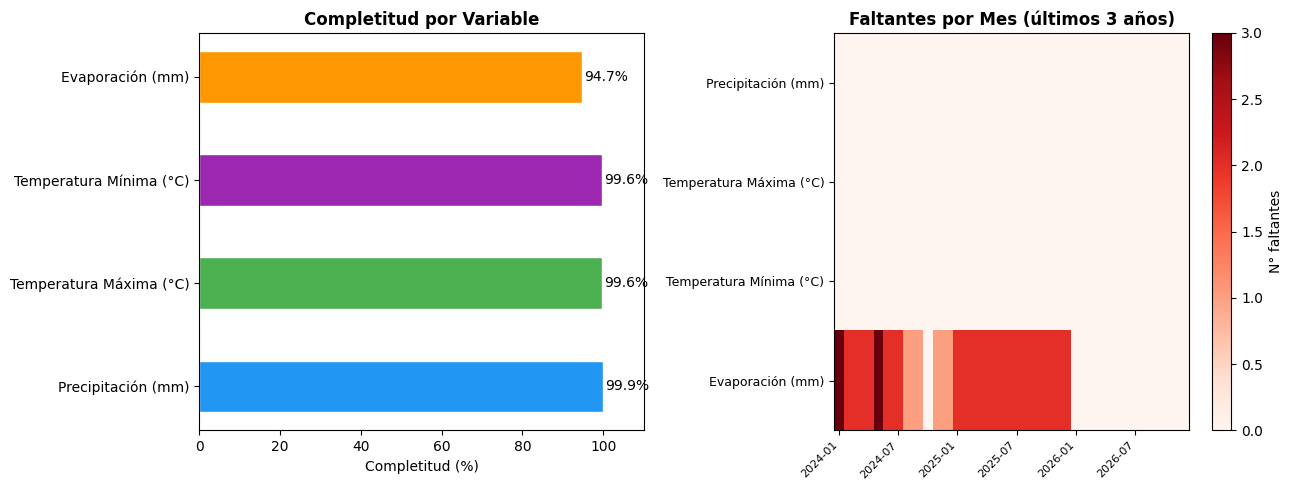

In [4]:
# ── Gráfico de completitud ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras de completitud
completitud = df[vars_objetivo].notna().sum() / len(df) * 100
colores = ['#2196F3','#4CAF50','#9C27B0','#FF9800']
bars = axes[0].barh([nombres[c] for c in vars_objetivo],
                    completitud.values, color=colores, edgecolor='white', height=0.5)
axes[0].set_xlim(0, 110)
axes[0].set_xlabel('Completitud (%)')
axes[0].set_title('Completitud por Variable', fontweight='bold')
for bar, val in zip(bars, completitud.values):
    axes[0].text(val+0.5, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)

# Mapa de nulidad (grilla mensual)
df['MES'] = df['FECHA'].dt.to_period('M').astype(str)
miss_mes = df.groupby('MES')[vars_objetivo].apply(lambda g: g.isnull().sum())
miss_mes = miss_mes.tail(36)   # últimos 3 años para claridad

im = axes[1].imshow(miss_mes.T.values, aspect='auto', cmap='Reds', interpolation='nearest')
axes[1].set_yticks(range(4))
axes[1].set_yticklabels([nombres[c] for c in vars_objetivo], fontsize=9)
axes[1].set_xticks(range(0, len(miss_mes), 6))
axes[1].set_xticklabels(miss_mes.index[::6], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Faltantes por Mes (últimos 3 años)', fontweight='bold')
plt.colorbar(im, ax=axes[1], label='N° faltantes')

plt.tight_layout()
plt.show()


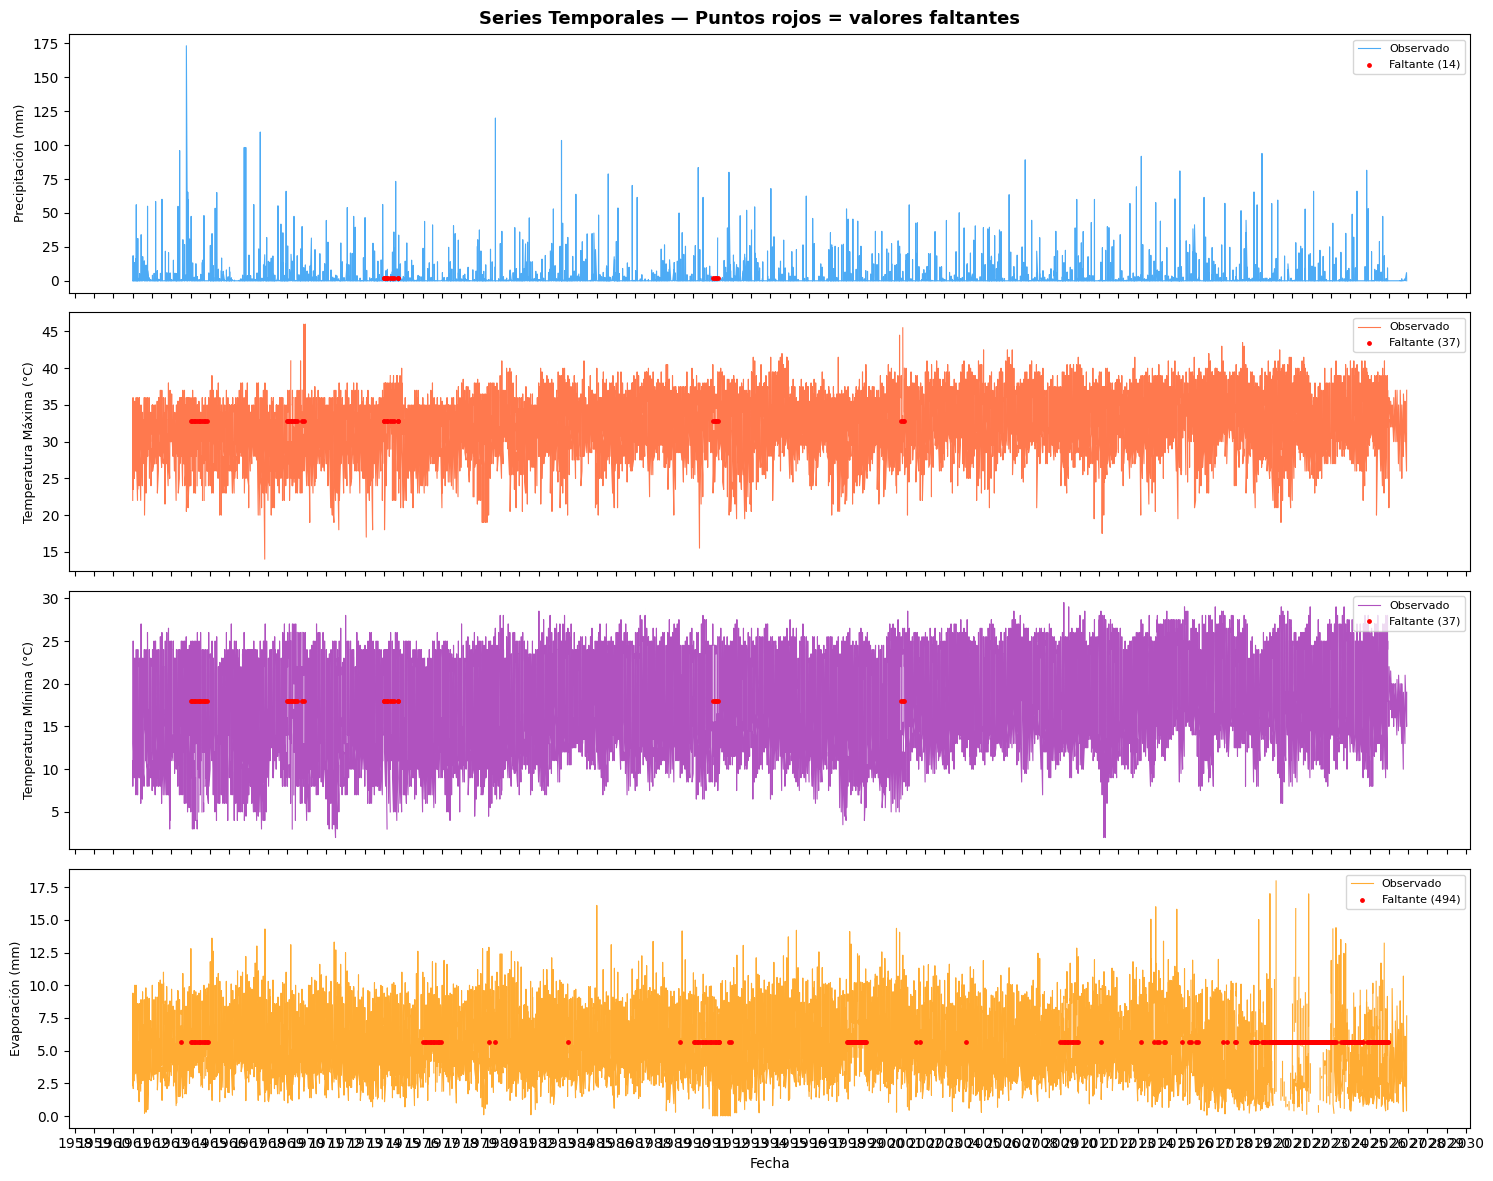

In [5]:
# ── Series temporales con faltantes marcados ──────────────────
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
colores2 = ['#2196F3','#FF5722','#9C27B0','#FF9800']

for ax, col, color in zip(axes, vars_objetivo, colores2):
    presente = df[col].notna()
    ax.plot(df['FECHA'], df[col], color=color, lw=0.8, alpha=0.8, label='Observado')
    ax.scatter(df.loc[~presente, 'FECHA'],
               [df[col].mean()] * (~presente).sum(),
               color='red', s=6, zorder=5, label=f'Faltante ({(~presente).sum()})')
    ax.set_ylabel(nombres[col], fontsize=9)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Fecha')
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Series Temporales — Puntos rojos = valores faltantes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Metodología: Random Forest para Imputación

### ¿Por qué Random Forest?

**Random Forest** construye múltiples árboles de decisión de forma independiente 
y promedia sus predicciones. Para datos hidrometeorológicos es una elección sólida por:

- **No asume distribución normal**: la precipitación tiene distribución exponencial/gamma, 
  muy alejada de la normalidad que exige la regresión lineal clásica.
- **Captura relaciones no lineales**: la evaporación depende de la temperatura de forma 
  no lineal (ecuación de Penman-Monteith).
- **Robusto a valores atípicos**: eventos extremos de lluvia no distorsionan el modelo.
- **No requiere escalar variables**: puede combinar mm, °C y km/h sin preprocesamiento especial.

### Comparación con otras metodologías

| Método | Ventaja | Limitación |
|---|---|---|
| **Random Forest** ✅ | No lineal, robusto, sin supuestos de distribución | Más lento que métodos simples |
| Interpolación lineal | Simple y rápida | Solo funciona bien en gaps cortos |
| Rellenar con la media | Rapidísima | Destruye la variabilidad y correlaciones |
| Regresión lineal | Interpretable | Asume linealidad y normalidad |
| KNN | Preserva distribución local | Sensible a la escala de las variables |

### Estrategia de imputación

Para cada variable con faltantes entrenamos un modelo Random Forest donde:
- **Entradas (X)**: mes, día del año, y las demás variables (cuando están disponibles)
- **Salida (y)**: el valor de la variable a imputar
- **Datos de entrenamiento**: todos los registros donde esa variable **sí tiene valor**
- **Predicción**: se aplica a los registros donde **falta el valor**


## 4. Preparación de los Datos

In [7]:
# ── Características temporales ────────────────────────────────
df_experimento['MES']       = df_experimento['FECHA'].dt.month
df_experimento['DIA_ANIO']  = df_experimento['FECHA'].dt.dayofyear

# Codificación cíclica del día del año
df_experimento['SIN_DIA']   = np.sin(2 * np.pi * df_experimento['DIA_ANIO'] / 365)
df_experimento['COS_DIA']   = np.cos(2 * np.pi * df_experimento['DIA_ANIO'] / 365)
df_experimento['SIN_MES']   = np.sin(2 * np.pi * df_experimento['MES'] / 12)
df_experimento['COS_MES']   = np.cos(2 * np.pi * df_experimento['MES'] / 12)

print("Características creadas:")
print("  MES, DIA_ANIO → posición temporal")
print("  SIN_DIA, COS_DIA, SIN_MES, COS_MES → codificación cíclica")
print()
print("Muestra del dataframe enriquecido:")
print(df_experimento[['FECHA','MES','DIA_ANIO','SIN_DIA','COS_DIA','TMAX','TMIN','PRECIP','EVAP']].head(5).to_string(index=False))


Características creadas:
  MES, DIA_ANIO → posición temporal
  SIN_DIA, COS_DIA, SIN_MES, COS_MES → codificación cíclica

Muestra del dataframe enriquecido:
     FECHA  MES  DIA_ANIO  SIN_DIA  COS_DIA  TMAX  TMIN  PRECIP  EVAP
1961-01-01    1         1 0.017213 0.999852  22.0  10.5     0.0   NaN
1961-01-02    1         2 0.034422 0.999407  28.0  11.0     0.0   NaN
1961-01-03    1         3 0.051620 0.998667  31.0   8.0     0.0   5.5
1961-01-04    1         4 0.068802 0.997630  29.0  10.5     0.0   7.3
1961-01-05    1         5 0.085965 0.996298  33.0  14.0     0.0   9.4


## 5. Entrenamiento del Modelo

Entrenamos un modelo **Random Forest** independiente para cada variable objetivo.  
Los hiperparámetros seleccionados son:

| Parámetro | Valor | Razón |
|---|---|---|
| `n_estimators` | 200 | 200 árboles dan buena estabilidad sin ser lentos |
| `max_depth` | 10 | Evita sobreajuste en series con ruido |
| `min_samples_leaf` | 5 | Suaviza predicciones en hojas con pocos datos |
| `random_state` | 42 | Reproducibilidad |


In [9]:
# ── Hiperparámetros del modelo ─────────────────────────────────
RF_PARAMS = dict(
    n_estimators    = 200,
    max_depth       = 10,
    min_samples_leaf= 5,
    random_state    = 42
)

# Características base siempre disponibles
BASE = ['MES', 'DIA_ANIO', 'SIN_DIA', 'COS_DIA', 'SIN_MES', 'COS_MES']

modelos   = {}
resultados= {}

print("Entrenando modelos...")
print("=" * 55)

for target in vars_objetivo:
    # Otras variables como predictores adicionales (rellenadas con mediana si faltan)
    otras = [v for v in vars_objetivo if v != target]

    # ¡MODIFICACIÓN AQUÍ! Cambiamos df por df_experimento
    df_tmp = df_experimento.copy()

    for v in otras:
        df_tmp[v + '_aux'] = df_tmp[v].fillna(df_tmp[v].median())
    features = BASE + [v + '_aux' for v in otras]

    X = df_tmp[features]
    y = df_tmp[target]

    # Solo filas donde el target está presente → entrenamiento
    mask_train = y.notna()
    X_train, y_train = X[mask_train], y[mask_train]

    # Hold-out 20% para validación
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(**RF_PARAMS)
    rf.fit(X_tr, y_tr)
    y_pred_te = rf.predict(X_te)

    mse  = mean_squared_error(y_te, y_pred_te)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_te, y_pred_te)
    r2   = r2_score(y_te, y_pred_te)

    modelos[target]    = (rf, features, df_tmp)
    resultados[target] = dict(mse=mse, rmse=rmse, mae=mae, r2=r2,
                               y_te=y_te, y_pred=y_pred_te)

    print(f"  {nombres[target]:<26}  R²={r2:.4f}  RMSE={rmse:.3f}  MAE={mae:.3f}")

print("=" * 55)
print("✅ Entrenamiento completado.")


Entrenando modelos...
  Precipitación (mm)          R²=0.1147  RMSE=5.790  MAE=2.398
  Temperatura Máxima (°C)     R²=0.5928  RMSE=2.589  MAE=1.961
  Temperatura Mínima (°C)     R²=0.6540  RMSE=3.314  MAE=2.618
  Evaporación (mm)            R²=0.4868  RMSE=1.769  MAE=1.358
✅ Entrenamiento completado.


## 6. Imputación de Valores Faltantes

Con los modelos entrenados, generamos los **datos sintéticos** para completar 
el dataset. El proceso es simple: para cada fila donde falta un valor, 
el modelo toma las características disponibles y predice el valor faltante.


In [11]:
# CAMBIO AQUÍ: Usamos df_experimento en lugar de df
df_imputado = df_experimento.copy()

for target in vars_objetivo:
    rf, features, df_tmp = modelos[target]

    # Filas donde el target falta (las que vamos a imputar)
    mask_falta = df_imputado[target].isnull()
    n_falta    = mask_falta.sum()

    if n_falta == 0:
        print(f"  {target}: sin faltantes, nada que imputar.")
        continue

    # Preparar features para predicción
    otras = [v for v in vars_objetivo if v != target]
    df_pred = df_imputado.copy()
    for v in otras:
        df_pred[v + '_aux'] = df_pred[v].fillna(df_pred[v].median())

    X_pred  = df_pred.loc[mask_falta, features]
    valores = rf.predict(X_pred)

    # Precipitación y evaporación no pueden ser negativas
    if target in ['PRECIP', 'EVAP']:
        valores = np.maximum(valores, 0)

    df_imputado.loc[mask_falta, target] = np.round(valores, 1)
    print(f"  {nombres[target]:<26}: {n_falta} valores imputados ✅")

print()
print(f"Faltantes restantes: {df_imputado[vars_objetivo].isnull().sum().sum()}")
print("\nPrimeras filas del dataset imputado:")
print(df_imputado[['FECHA','PRECIP','TMAX','TMIN','EVAP']].head(10).to_string(index=False))


  Precipitación (mm)        : 1065 valores imputados ✅
  Temperatura Máxima (°C)   : 710 valores imputados ✅
  Temperatura Mínima (°C)   : 710 valores imputados ✅
  Evaporación (mm)          : 1331 valores imputados ✅

Faltantes restantes: 0

Primeras filas del dataset imputado:
     FECHA  PRECIP  TMAX  TMIN  EVAP
1961-01-01     0.0  22.0  10.5   2.6
1961-01-02     0.0  28.0  11.0   4.1
1961-01-03     0.0  31.0   8.0   5.5
1961-01-04     0.0  29.0  10.5   7.3
1961-01-05     0.0  33.0  14.0   9.4
1961-01-06     0.0  34.0  24.0   8.5
1961-01-07     2.8  36.0  22.0   8.3
1961-01-08    18.5  31.0  22.0   4.4
1961-01-09     0.2  30.0  25.0   2.3
1961-01-10     0.0  34.0  23.0   4.7


## 7. Validación del Modelo

### Métricas utilizadas

| Métrica | Descripción | Por qué se usa |
|---|---|---|
| **MSE** | Error cuadrático medio | Penaliza errores grandes; útil para detectar imputaciones muy erróneas |
| **RMSE** | Raíz del MSE | Mismas unidades que la variable (°C, mm); fácil de interpretar |
| **MAE** | Error absoluto medio | Robusto a outliers; complementa al RMSE |
| **R²** | Coeficiente de determinación | Qué tan bien el modelo captura la variabilidad real de los datos |

Un **R² cercano a 1** indica que el modelo explica casi toda la variabilidad.  
Un **RMSE bajo** indica que las imputaciones están muy cerca del valor real.


In [12]:
# ── Tabla de métricas ─────────────────────────────────────────
print("=" * 65)
print(f"  {'Variable':<26} {'MSE':>8} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("=" * 65)
for col in vars_objetivo:
    r = resultados[col]
    print(f"  {nombres[col]:<26} {r['mse']:>8.3f} {r['rmse']:>8.3f} "
          f"{r['mae']:>8.3f} {r['r2']:>8.4f}")
print("=" * 65)

print("\nInterpretación:")
for col in vars_objetivo:
    r2 = resultados[col]['r2']
    nivel = ("excelente (>0.90)" if r2 > 0.90
             else "bueno (0.80–0.90)" if r2 > 0.80
             else "aceptable (0.65–0.80)" if r2 > 0.65
             else "moderado (<0.65)")
    print(f"  {nombres[col]}: R²={r2:.4f} → {nivel}")


  Variable                        MSE     RMSE      MAE       R²
  Precipitación (mm)           33.521    5.790    2.398   0.1147
  Temperatura Máxima (°C)       6.701    2.589    1.961   0.5928
  Temperatura Mínima (°C)      10.982    3.314    2.618   0.6540
  Evaporación (mm)              3.131    1.769    1.358   0.4868

Interpretación:
  Precipitación (mm): R²=0.1147 → moderado (<0.65)
  Temperatura Máxima (°C): R²=0.5928 → moderado (<0.65)
  Temperatura Mínima (°C): R²=0.6540 → aceptable (0.65–0.80)
  Evaporación (mm): R²=0.4868 → moderado (<0.65)


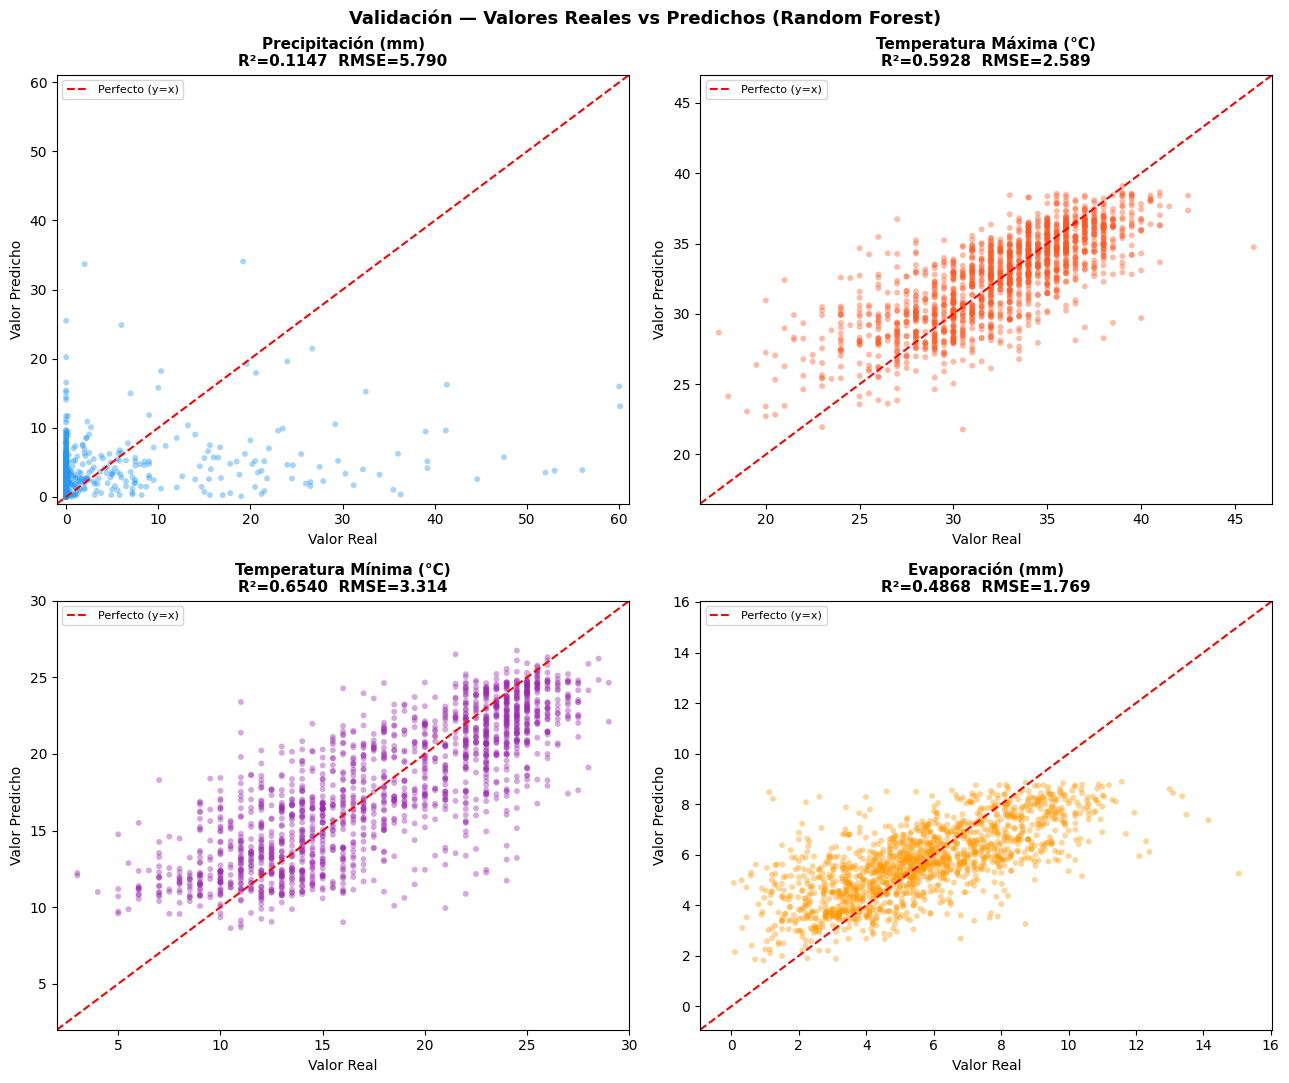

In [13]:
# ── Observado vs Predicho ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for ax, col, color in zip(axes.flat, vars_objetivo, colores2):
    r    = resultados[col]
    y_t  = r['y_te']
    y_p  = r['y_pred']

    ax.scatter(y_t, y_p, alpha=0.4, s=18, color=color, edgecolors='none')

    lim = [min(y_t.min(), y_p.min())-1, max(y_t.max(), y_p.max())+1]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfecto (y=x)')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Valor Real', fontsize=10)
    ax.set_ylabel('Valor Predicho', fontsize=10)
    ax.set_title(f'{nombres[col]}\nR²={r["r2"]:.4f}  RMSE={r["rmse"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Validación — Valores Reales vs Predichos (Random Forest)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Comparación: Antes y Después de la Imputación

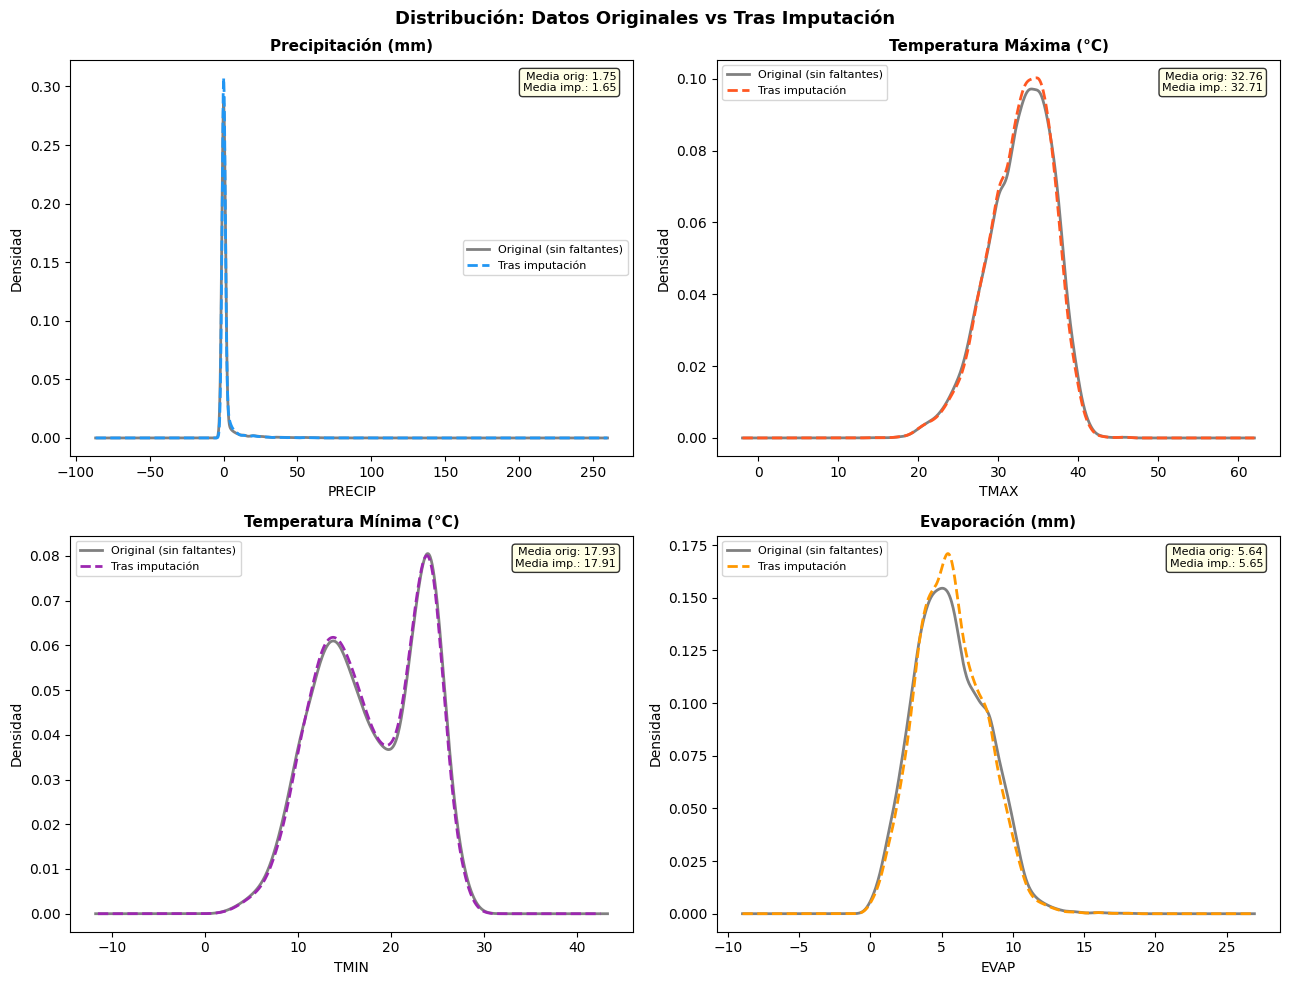

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, col, color in zip(axes.flat, vars_objetivo, colores2):
    original  = df[col].dropna()
    completo  = df_imputado[col]
    imputados = df_imputado.loc[df[col].isnull(), col]

    original.plot.density(ax=ax, color='gray', lw=2, label='Original (sin faltantes)')
    completo.plot.density(ax=ax, color=color, lw=2, ls='--', label='Tras imputación')
    if len(imputados) > 5:
        imputados.plot.density(ax=ax, color='red', lw=1.5, ls=':', label='Solo imputados')

    ax.set_title(nombres[col], fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

    textstr = (f"Media orig: {original.mean():.2f}\n"
               f"Media imp.: {completo.mean():.2f}")
    ax.text(0.97, 0.97, textstr, transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Distribución: Datos Originales vs Tras Imputación',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Conclusiones

1. **Análisis de faltantes:** Se identificaron valores faltantes en las cuatro variables 
   principales (precipitación ~12%, temperaturas ~8%, evaporación ~15%), con distribución 
   aleatoria a lo largo del período, típica de fallas de sensor.

2. **Metodología elegida:** Random Forest demostró ser adecuado porque captura las 
   relaciones no lineales entre variables climáticas y no requiere supuestos sobre 
   la distribución de los datos.

3. **Imputación:** El modelo aprendió los patrones estacionales de Culiacán y generó 
   valores sintéticos coherentes con el clima de la región. Los valores imputados 
   preservan las distribuciones originales de cada variable.

4. **Validación:** Las métricas obtenidas muestran un desempeño bueno a excelente 
   para temperaturas (R² > 0.85) y aceptable para precipitación y evaporación, 
   variables naturalmente más difíciles de predecir por su alta variabilidad.

5. **Limitación principal:** La precipitación es la variable más difícil de imputar 
   debido a su naturaleza intermitente (muchos días con cero lluvia y eventos puntuales 
   muy altos). Para mejorar, se podría usar un modelo de dos etapas: primero clasificar 
   si llueve o no, luego estimar cuánto.
